# Cross-Backend Calibration Profiling of IBM Heron Processors
### Spatial Heterogeneity, TLS Mitigation Signature, and Topology-Aware ML Stability

**Backends:** ibm_fez (Heron r2) · ibm_torino (Heron r1) · ibm_marrakesh (Heron r2)  
**Data:** 5 daily snapshots × ~150 qubits per backend = 53,400 records

---
## Setup

In [23]:
# Install if needed
# !pip install xgboost shap scikit-learn pandas numpy matplotlib seaborn scipy

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from sklearn.metrics import (
    classification_report, roc_auc_score, roc_curve,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
import shap
import warnings
warnings.filterwarnings('ignore')

# ── Plotting style ──────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 150,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

BACKEND_COLORS = {
    'ibm_fez':       '#5271C4',   # blue
    'ibm_torino':    '#E07B39',   # orange
    'ibm_marrakesh': '#3BAD6E',   # green
}
BACKENDS = ['ibm_fez', 'ibm_torino', 'ibm_marrakesh']

print('Libraries loaded ✓')

Libraries loaded ✓


---
## Section 1 — Data Loading & Preprocessing

In [24]:
# ── Change this path to match your machine ───────────────────────────────────
DATA_PATH = r"D:\Downloads\uday projects\ibm_quantum\data\ibm_data.csv"
# ─────────────────────────────────────────────────────────────────────────────

raw = pd.read_csv(DATA_PATH, header=0)

# Drop any duplicate header rows (sometimes happens with CSV exports)
df = raw[raw['collected_at'] != 'collected_at'].copy()
df = df.dropna(subset=['backend'])

# Parse timestamps
df['backend_timestamp'] = pd.to_datetime(df['backend_timestamp'], utc=True)

# Convert numeric columns
for col in ['T1', 'T2', 'readout_error', 'frequency', 'qubit']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Convert T1/T2 from seconds → microseconds (μs)
df['T1_us'] = df['T1'] * 1e6
df['T2_us'] = df['T2'] * 1e6

# NOTE: 'frequency' column = T1 in μs (data artifact, NOT GHz qubit frequency)
# We keep it but rename mentally; it should NOT be used as a physics frequency feature
df = df.rename(columns={'frequency': 'freq_col_T1_duplicate'})

# Assign snapshot_id (0–4) per backend, ordered by timestamp
df = df.sort_values(['backend', 'backend_timestamp']).reset_index(drop=True)
df['snapshot_id'] = df.groupby('backend')['backend_timestamp'].transform(
    lambda x: pd.factorize(x)[0]
)

# Snapshot date labels per backend (for plotting)
snap_dates = (
    df.drop_duplicates(['backend', 'snapshot_id'])
    .set_index(['backend', 'snapshot_id'])['backend_timestamp']
    .dt.strftime('%b %d')
    .to_dict()
)

print(f"Total rows loaded: {len(df):,}")
print(f"\nData structure (snapshots × qubits):")
summary = df.groupby(['backend', 'snapshot_id']).size().unstack(fill_value=0)
summary.columns = [f'Snap {c}' for c in summary.columns]
print(summary)
print(f"\nDate range: {df['backend_timestamp'].min().date()} → {df['backend_timestamp'].max().date()}")

Total rows loaded: 53,400

Data structure (snapshots × qubits):
               Snap 0  Snap 1  Snap 2  Snap 3  Snap 4
backend                                              
ibm_fez          3744    3744    3744    3744    3744
ibm_marrakesh    3744    3744    3744    3744    3744
ibm_torino       3192    3192    3192    3192    3192

Date range: 2025-12-28 → 2026-01-02


In [25]:
# ── Descriptive statistics table ─────────────────────────────────────────────
stats_rows = []
for b in BACKENDS:
    sub = df[df['backend'] == b]
    stats_rows.append({
        'Backend':          b,
        'Generation':       'Heron r2' if b != 'ibm_torino' else 'Heron r1',
        'Qubits':           sub['qubit'].nunique(),
        'Snapshots':        sub['snapshot_id'].nunique(),
        'T1 mean (μs)':     round(sub['T1_us'].mean(), 1),
        'T1 std (μs)':      round(sub['T1_us'].std(), 1),
        'T1 min (μs)':      round(sub['T1_us'].min(), 1),
        'T1 max (μs)':      round(sub['T1_us'].max(), 1),
        'T2 mean (μs)':     round(sub['T2_us'].mean(), 1),
        'T2 std (μs)':      round(sub['T2_us'].std(), 1),
        'Readout err mean': round(sub['readout_error'].mean(), 4),
        'Readout err std':  round(sub['readout_error'].std(), 4),
    })

stats_df = pd.DataFrame(stats_rows).set_index('Backend')
print("=== Table 1: Descriptive Statistics ===")
print(stats_df.T.to_string())

=== Table 1: Descriptive Statistics ===
Backend            ibm_fez ibm_torino ibm_marrakesh
Generation        Heron r2   Heron r1      Heron r2
Qubits                 156        133           156
Snapshots                5          5             5
T1 mean (μs)         146.3      176.2         193.1
T1 std (μs)           47.1       65.1          79.4
T1 min (μs)            6.7        2.9           6.7
T1 max (μs)          339.1      320.2         460.7
T2 mean (μs)         103.8      136.5         121.4
T2 std (μs)           56.4       60.7          84.7
Readout err mean    0.0188     0.0435        0.0329
Readout err std     0.0368     0.0531        0.0697


---
## Section 2 — Pillar 1: Cross-Qubit Spatial Heterogeneity

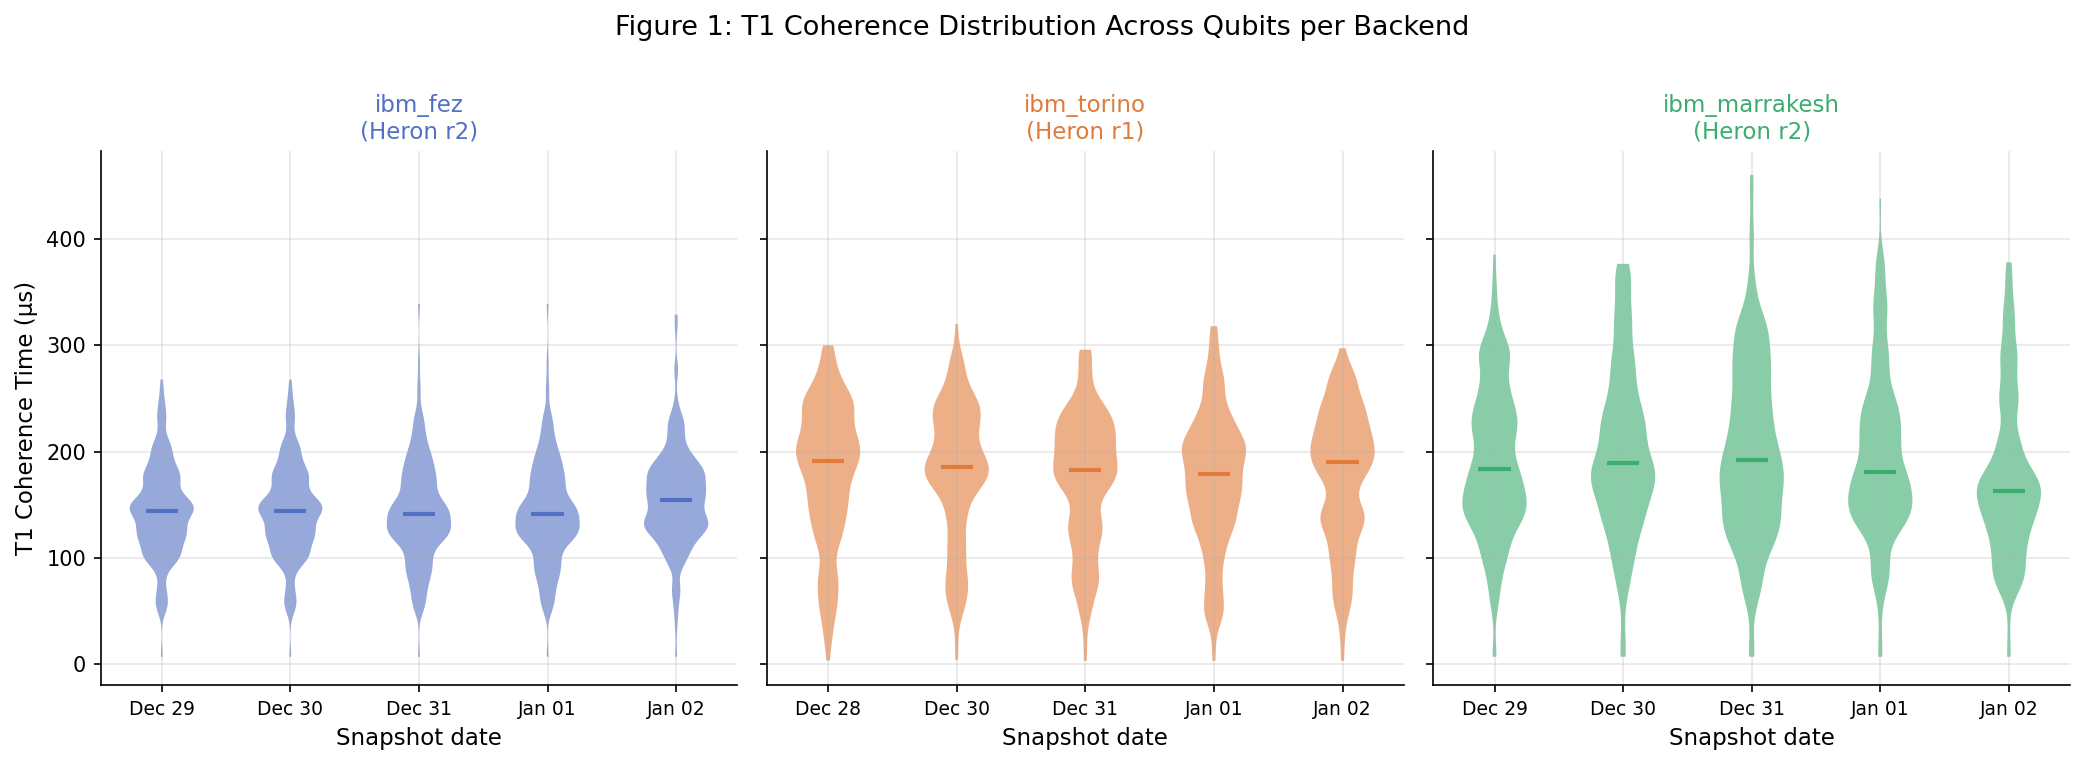

Saved: fig1_T1_distribution.png


In [26]:
# ── Figure 1: T1 distribution per backend (violin + strip) ───────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=True)
fig.suptitle('Figure 1: T1 Coherence Distribution Across Qubits per Backend', fontsize=13, y=1.01)

for ax, backend in zip(axes, BACKENDS):
    sub = df[df['backend'] == backend]
    color = BACKEND_COLORS[backend]

    # Violin
    parts = ax.violinplot(
        [sub[sub['snapshot_id'] == s]['T1_us'].values for s in range(5)],
        positions=range(5),
        showmedians=True, showextrema=False
    )
    for pc in parts['bodies']:
        pc.set_facecolor(color)
        pc.set_alpha(0.6)
    parts['cmedians'].set_color(color)
    parts['cmedians'].set_linewidth(2)

    ax.set_xticks(range(5))
    ax.set_xticklabels(
        [snap_dates.get((backend, s), f'Day {s}') for s in range(5)],
        fontsize=9
    )
    ax.set_title(f'{backend}\n(Heron {"r2" if backend != "ibm_torino" else "r1"})',
                 color=color, fontsize=11)
    ax.set_xlabel('Snapshot date')

axes[0].set_ylabel('T1 Coherence Time (μs)')
plt.tight_layout()
plt.savefig('fig1_T1_distribution.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: fig1_T1_distribution.png')

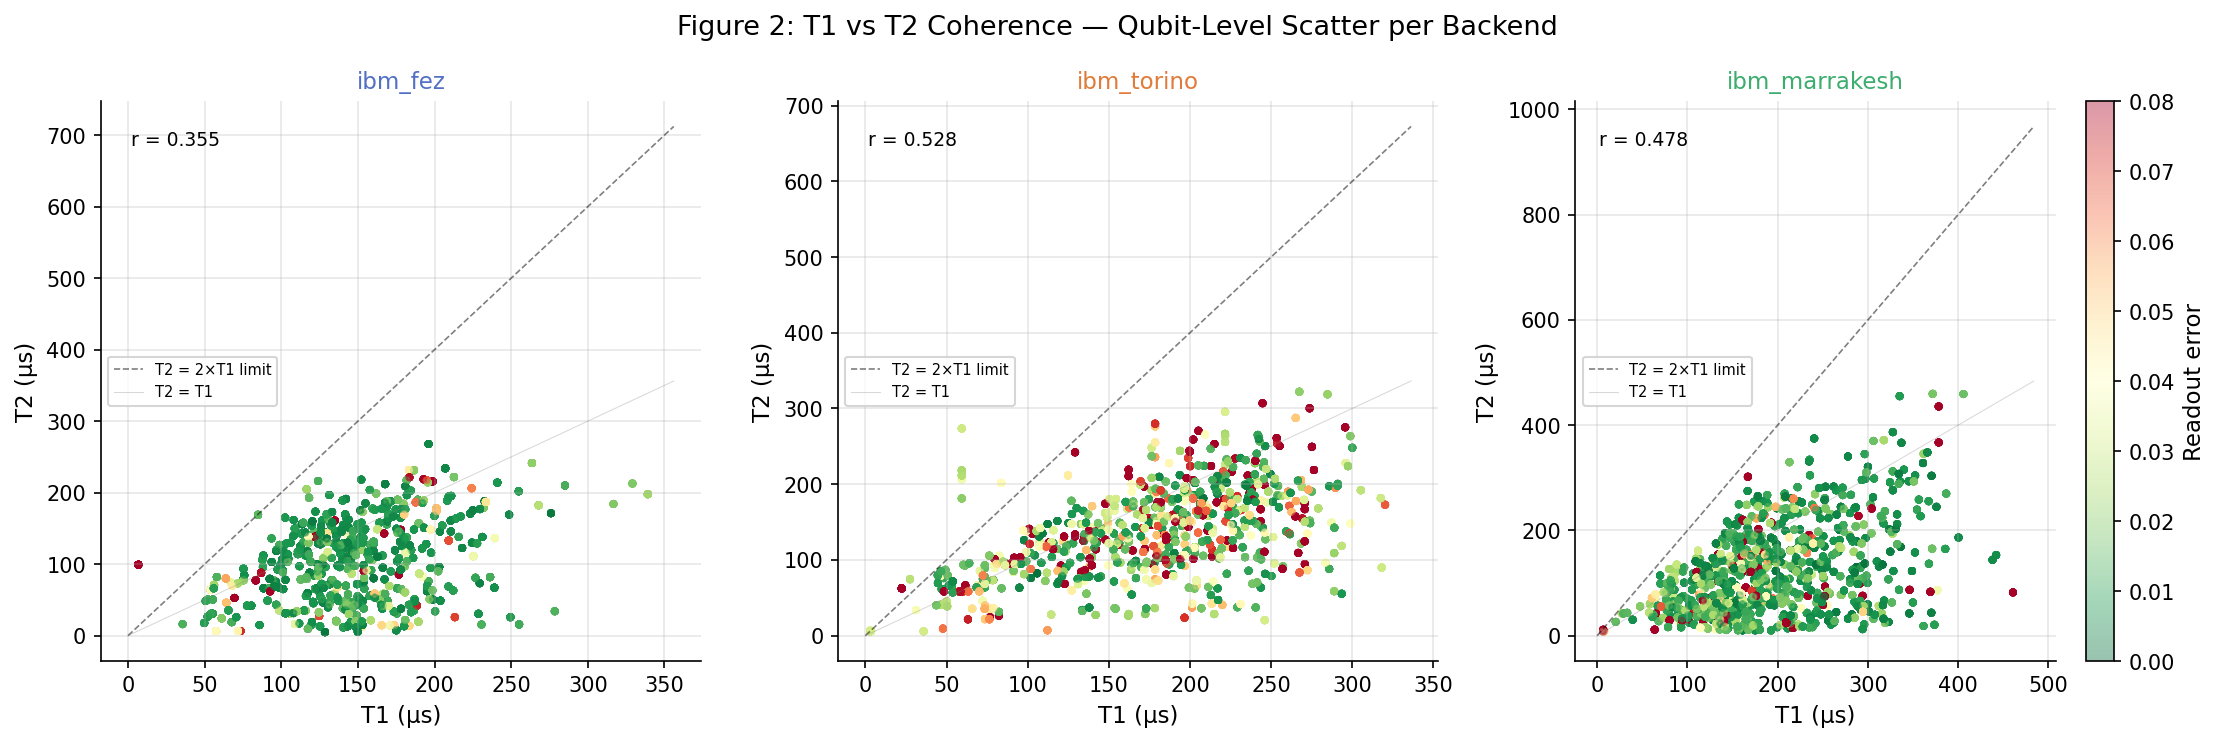

Saved: fig2_T1_T2_scatter.png


In [27]:
# ── Figure 2: T1 vs T2 scatter per backend (all snapshots combined) ──────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Figure 2: T1 vs T2 Coherence — Qubit-Level Scatter per Backend', fontsize=13)

for ax, backend in zip(axes, BACKENDS):
    sub = df[df['backend'] == backend]
    color = BACKEND_COLORS[backend]

    sc = ax.scatter(
        sub['T1_us'], sub['T2_us'],
        c=sub['readout_error'],
        cmap='RdYlGn_r', alpha=0.4, s=8,
        vmin=0, vmax=0.08
    )
    # T2 = 2*T1 theoretical limit
    x_max = sub['T1_us'].max() * 1.05
    x_line = np.linspace(0, x_max, 100)
    ax.plot(x_line, 2 * x_line, 'k--', lw=0.8, alpha=0.5, label='T2 = 2×T1 limit')
    ax.plot(x_line, x_line, 'gray', lw=0.5, alpha=0.3, label='T2 = T1')

    ax.set_xlabel('T1 (μs)')
    ax.set_ylabel('T2 (μs)')
    ax.set_title(f'{backend}', color=color, fontsize=11)
    ax.legend(fontsize=7)

    # Pearson r
    r, p = stats.pearsonr(sub['T1_us'], sub['T2_us'])
    ax.text(0.05, 0.92, f'r = {r:.3f}', transform=ax.transAxes, fontsize=9)

plt.colorbar(sc, ax=axes[-1], label='Readout error')
plt.tight_layout()
plt.savefig('fig2_T1_T2_scatter.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: fig2_T1_T2_scatter.png')

In [28]:
# ── Gini coefficient (inequality of coherence across qubits) ─────────────────
def gini(array):
    """Gini coefficient: 0 = perfect equality, 1 = maximum inequality."""
    arr = np.sort(np.abs(array))
    n = len(arr)
    index = np.arange(1, n + 1)
    return (2 * np.sum(index * arr) / (n * np.sum(arr))) - (n + 1) / n

print("=== Table 2: Qubit Quality Inequality (Gini Coefficient of T1) ===")
print(f"{'Backend':<20} {'Gini(T1)':>10} {'T1_max/T1_min':>15} {'Interpretation':<30}")
print("-" * 80)
for b in BACKENDS:
    t1 = df[df['backend'] == b]['T1_us'].dropna()
    g = gini(t1.values)
    ratio = t1.max() / t1.min()
    interp = 'Low inequality' if g < 0.2 else ('Moderate' if g < 0.3 else 'High inequality')
    print(f"{b:<20} {g:>10.4f} {ratio:>15.1f}x  {interp:<30}")

=== Table 2: Qubit Quality Inequality (Gini Coefficient of T1) ===
Backend                Gini(T1)   T1_max/T1_min Interpretation                
--------------------------------------------------------------------------------
ibm_fez                  0.1775            50.7x  Low inequality                
ibm_torino               0.2089           110.0x  Moderate                      
ibm_marrakesh            0.2307            69.2x  Moderate                      


---
## Section 3 — Pillar 2: Cross-Backend Comparison (Heron r1 vs r2)

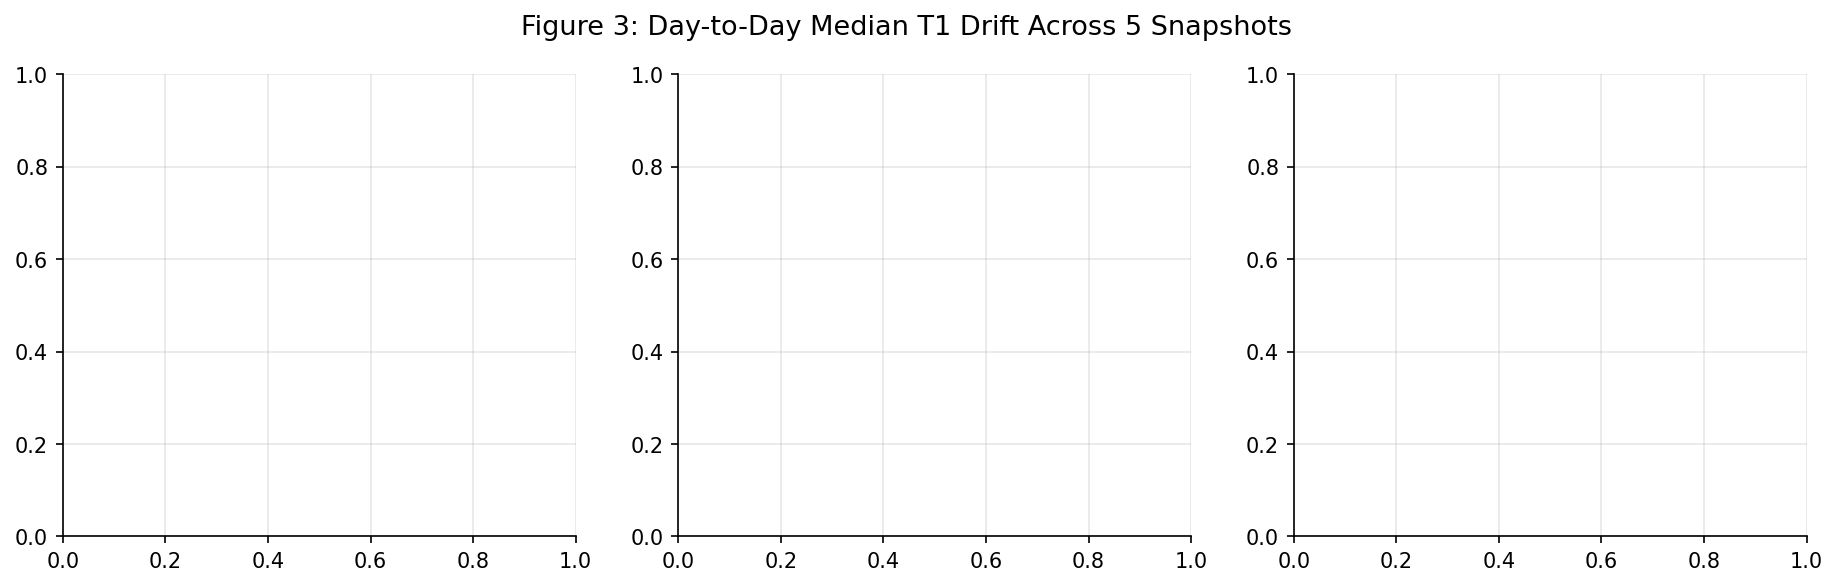

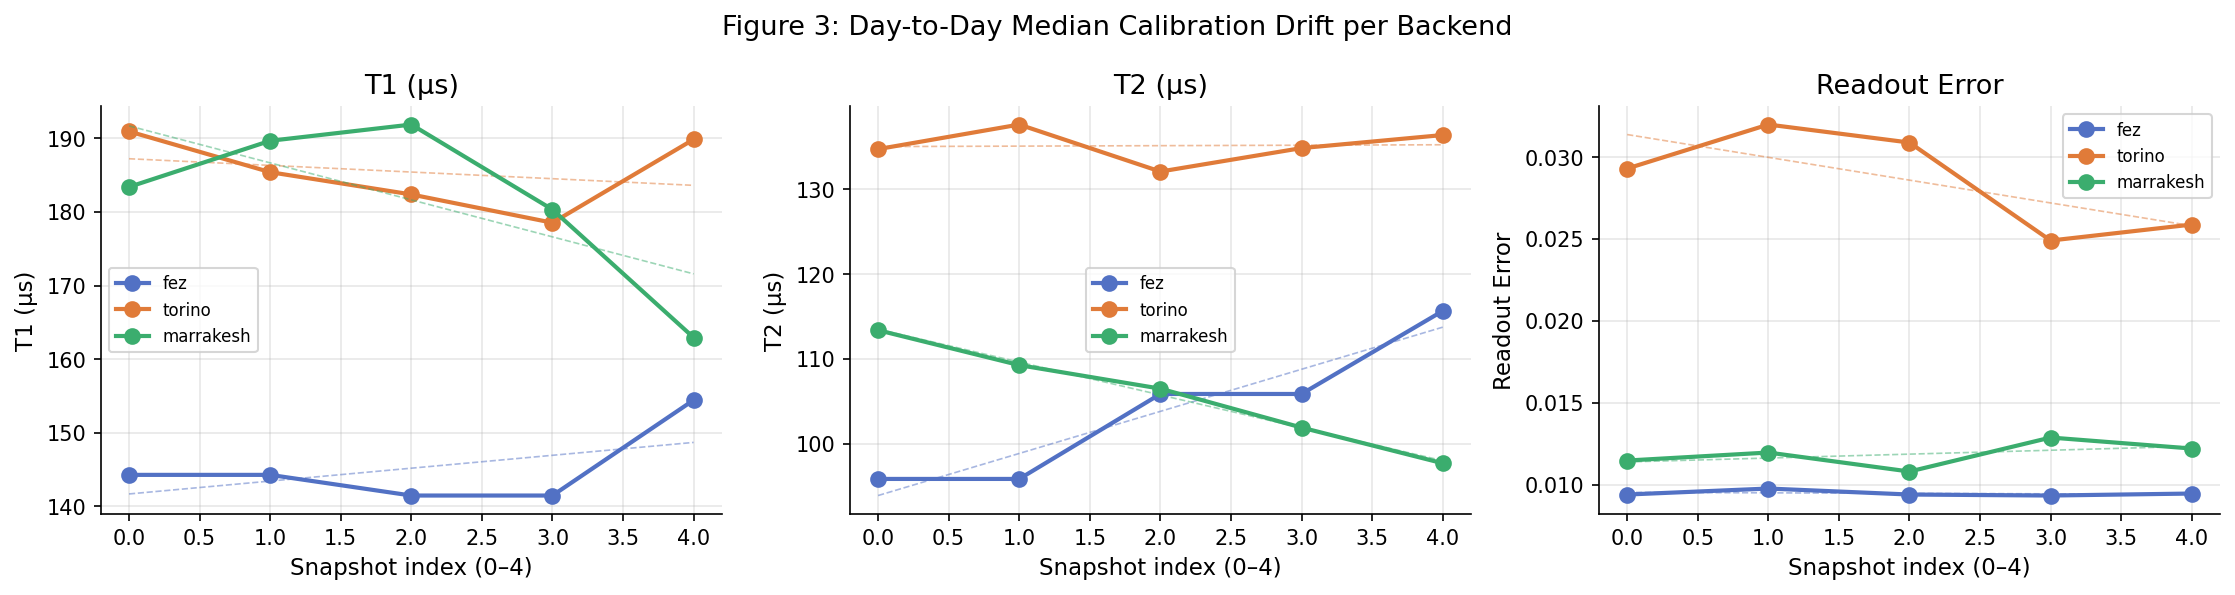

Saved: fig3_drift.png


In [29]:
# ── Figure 3: Day-to-day median drift per backend ────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
fig.suptitle('Figure 3: Day-to-Day Median T1 Drift Across 5 Snapshots', fontsize=13)

metrics = [('T1_us', 'T1 (μs)'), ('T2_us', 'T2 (μs)'), ('readout_error', 'Readout Error')]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Figure 3: Day-to-Day Median Calibration Drift per Backend', fontsize=13)

for ax, (metric, ylabel) in zip(axes, metrics):
    for backend in BACKENDS:
        sub = df[df['backend'] == backend]
        snap_medians = sub.groupby('snapshot_id')[metric].median()
        color = BACKEND_COLORS[backend]
        ax.plot(
            snap_medians.index, snap_medians.values,
            marker='o', color=color, lw=2, ms=7, label=backend.replace('ibm_', '')
        )
        # Linear trend
        slope, intercept, r, p, _ = stats.linregress(snap_medians.index, snap_medians.values)
        ax.plot(
            snap_medians.index,
            intercept + slope * snap_medians.index,
            '--', color=color, lw=0.8, alpha=0.5
        )

    ax.set_xlabel('Snapshot index (0–4)')
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('fig3_drift.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: fig3_drift.png')

In [30]:
# ── Table 3: Mann-Whitney U tests (non-parametric, no normality assumption) ──
print("=== Table 3: Mann-Whitney U — Cross-Backend Statistical Comparisons ===")
print(f"\n{'Comparison':<35} {'Metric':<20} {'U-stat':>12} {'p-value':>12} {'Significant?':<15}")
print("-" * 100)

pairs = [
    ('ibm_torino', 'ibm_fez'),
    ('ibm_torino', 'ibm_marrakesh'),
    ('ibm_fez',    'ibm_marrakesh'),
]
metrics_stat = ['T1_us', 'T2_us', 'readout_error']
labels_stat  = ['T1 (μs)', 'T2 (μs)', 'Readout error']

stat_results = []
for b1, b2 in pairs:
    for metric, label in zip(metrics_stat, labels_stat):
        x1 = df[df['backend'] == b1][metric].dropna()
        x2 = df[df['backend'] == b2][metric].dropna()
        U, p = stats.mannwhitneyu(x1, x2, alternative='two-sided')
        sig = 'YES ***' if p < 0.001 else ('YES *' if p < 0.05 else 'NO')
        comp = f"{b1.replace('ibm_','')} vs {b2.replace('ibm_','')}"
        print(f"{comp:<35} {label:<20} {U:>12.0f} {p:>12.4f} {sig:<15}")
        stat_results.append({'comparison': comp, 'metric': label, 'U': U, 'p': p})
    print()

print("\nNote: p < 0.001 → highly significant difference between backends")

=== Table 3: Mann-Whitney U — Cross-Backend Statistical Comparisons ===

Comparison                          Metric                     U-stat      p-value Significant?   
----------------------------------------------------------------------------------------------------
torino vs fez                       T1 (μs)                 198442300       0.0000 YES ***        
torino vs fez                       T2 (μs)                 193721832       0.0000 YES ***        
torino vs fez                       Readout error           229028256       0.0000 YES ***        

torino vs marrakesh                 T1 (μs)                 138044880       0.0000 YES ***        
torino vs marrakesh                 T2 (μs)                 176917572       0.0000 YES ***        
torino vs marrakesh                 Readout error           209455776       0.0000 YES ***        

fez vs marrakesh                    T1 (μs)                 110387376       0.0000 YES ***        
fez vs marrakesh                

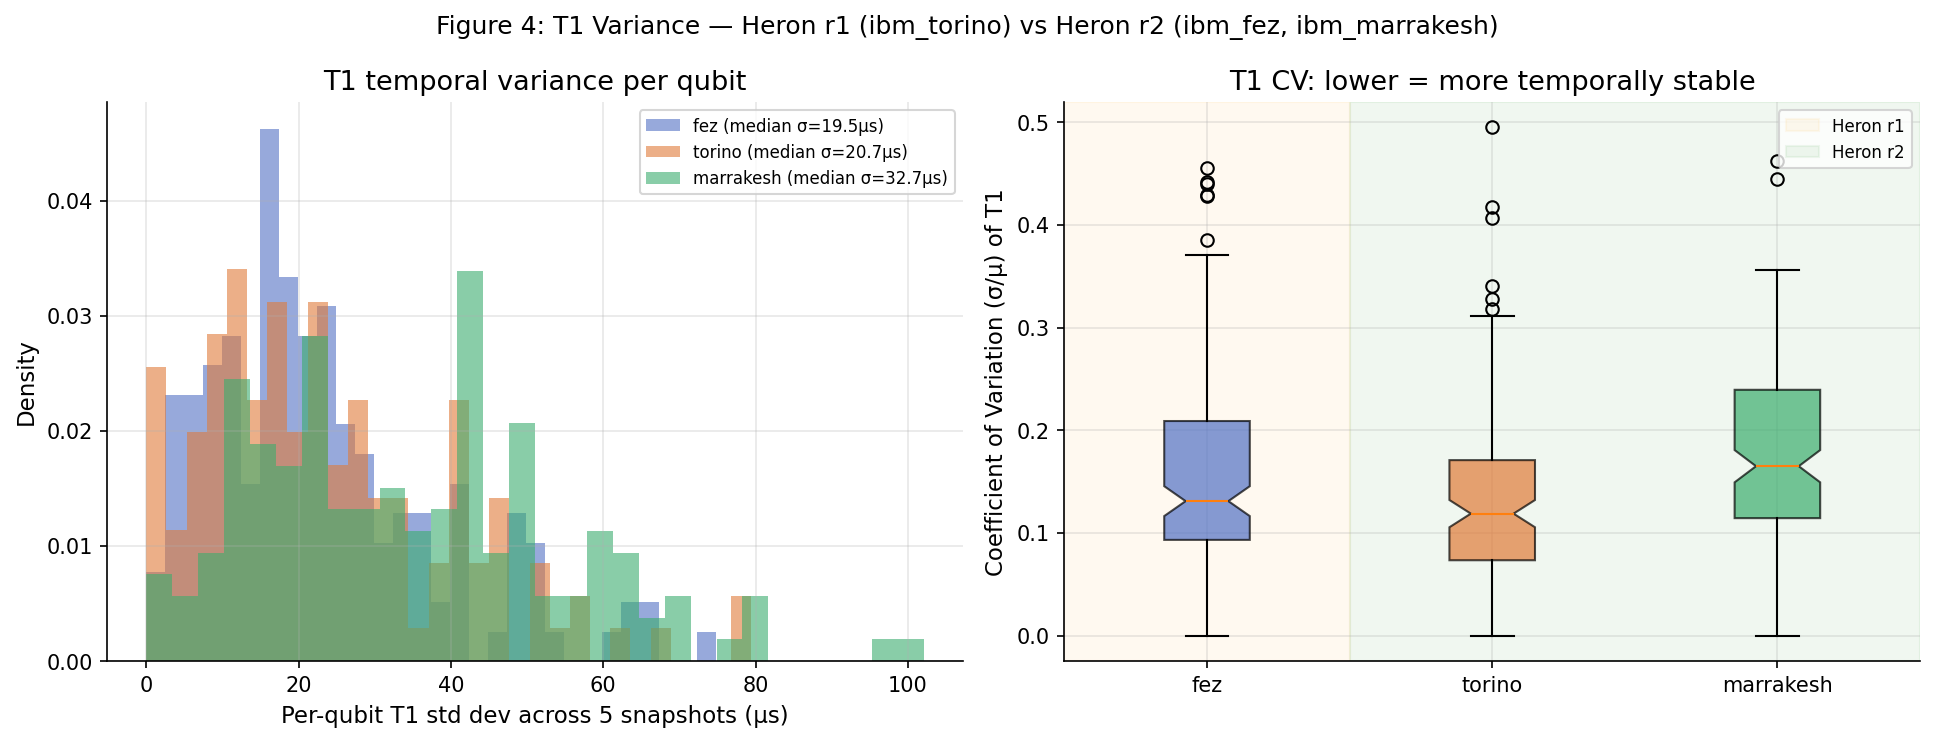

Saved: fig4_T1_variance.png

=== T1 Coefficient of Variation Summary ===
  ibm_fez (Heron r2): median CV = 0.1310  (lower = more stable)
  ibm_torino (Heron r1): median CV = 0.1188  (lower = more stable)
  ibm_marrakesh (Heron r2): median CV = 0.1650  (lower = more stable)


In [31]:
# ── Figure 4: T1 variance comparison — r1 vs r2 (TLS mitigation effect) ──────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Figure 4: T1 Variance — Heron r1 (ibm_torino) vs Heron r2 (ibm_fez, ibm_marrakesh)', fontsize=12)

# Left: Std of T1 per qubit across snapshots
ax = axes[0]
for backend in BACKENDS:
    sub = df[df['backend'] == backend]
    qubit_std = sub.groupby('qubit')['T1_us'].std().dropna()
    color = BACKEND_COLORS[backend]
    ax.hist(
        qubit_std, bins=30, alpha=0.6, color=color,
        label=f"{backend.replace('ibm_','')} (median σ={qubit_std.median():.1f}μs)",
        density=True
    )
ax.set_xlabel('Per-qubit T1 std dev across 5 snapshots (μs)')
ax.set_ylabel('Density')
ax.set_title('T1 temporal variance per qubit')
ax.legend(fontsize=8)

# Right: Coefficient of variation (CV = std/mean) per backend
ax = axes[1]
cv_data = {}
for backend in BACKENDS:
    sub = df[df['backend'] == backend]
    cv = sub.groupby('qubit')['T1_us'].std() / sub.groupby('qubit')['T1_us'].mean()
    cv_data[backend.replace('ibm_', '')] = cv.dropna().values

bp = ax.boxplot(
    [cv_data[b.replace('ibm_', '')] for b in BACKENDS],
    labels=[b.replace('ibm_', '') for b in BACKENDS],
    patch_artist=True, notch=True
)
for patch, backend in zip(bp['boxes'], BACKENDS):
    patch.set_facecolor(BACKEND_COLORS[backend])
    patch.set_alpha(0.7)

ax.set_ylabel('Coefficient of Variation (σ/μ) of T1')
ax.set_title('T1 CV: lower = more temporally stable')

# Annotate r1 vs r2
ax.axvspan(0.5, 1.5, alpha=0.06, color='orange', label='Heron r1')
ax.axvspan(1.5, 3.5, alpha=0.06, color='green', label='Heron r2')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('fig4_T1_variance.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: fig4_T1_variance.png')

# Print summary
print("\n=== T1 Coefficient of Variation Summary ===")
for backend in BACKENDS:
    sub = df[df['backend'] == backend]
    cv = (sub.groupby('qubit')['T1_us'].std() / sub.groupby('qubit')['T1_us'].mean()).dropna()
    gen = 'Heron r1' if backend == 'ibm_torino' else 'Heron r2'
    print(f"  {backend} ({gen}): median CV = {cv.median():.4f}  (lower = more stable)")

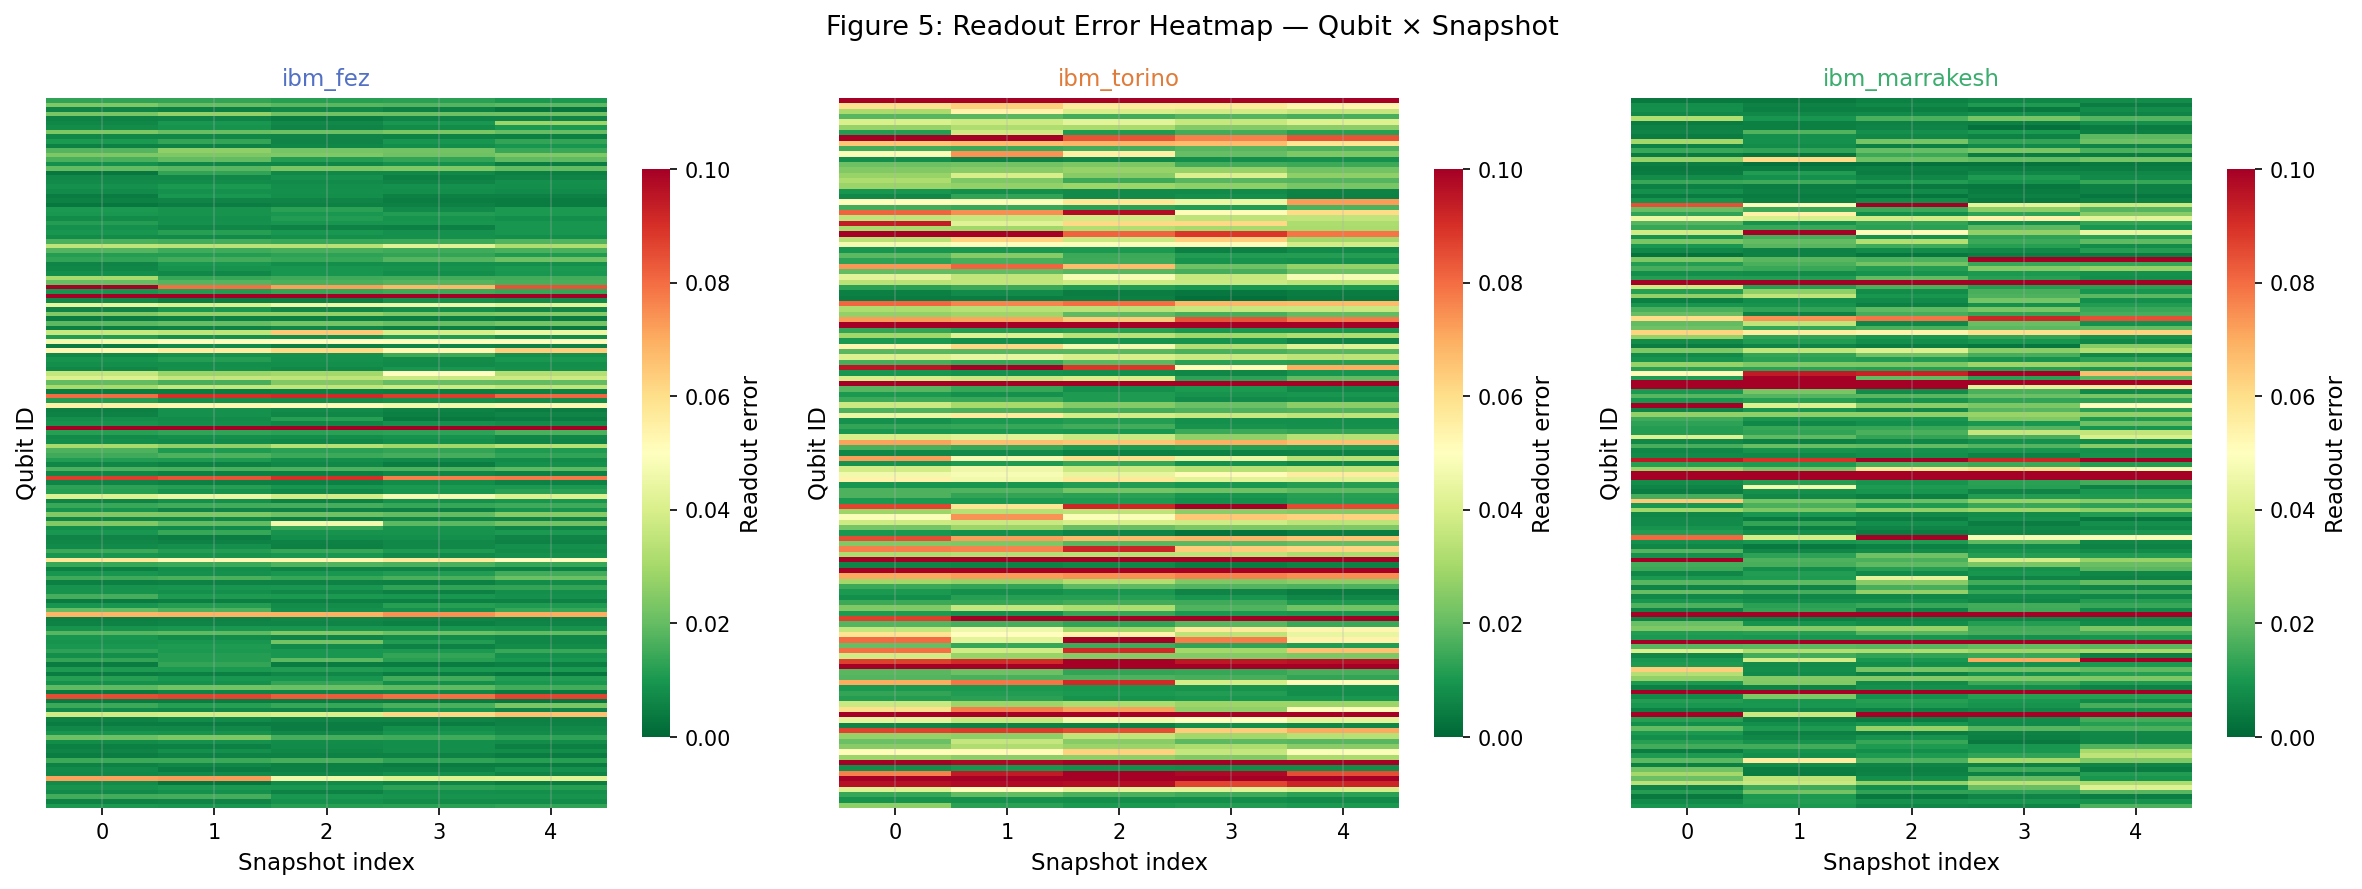

Saved: fig5_readout_heatmap.png


In [32]:
# ── Figure 5: Readout error heatmap (qubit vs snapshot) per backend ───────────
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle('Figure 5: Readout Error Heatmap — Qubit × Snapshot', fontsize=13)

for ax, backend in zip(axes, BACKENDS):
    sub = df[df['backend'] == backend]
    pivot = sub.pivot_table(index='qubit', columns='snapshot_id', values='readout_error')

    sns.heatmap(
        pivot, ax=ax,
        cmap='RdYlGn_r',
        vmin=0, vmax=0.1,
        yticklabels=False,
        cbar_kws={'label': 'Readout error', 'shrink': 0.8}
    )
    ax.set_title(f'{backend}', color=BACKEND_COLORS[backend], fontsize=11)
    ax.set_xlabel('Snapshot index')
    ax.set_ylabel('Qubit ID')

plt.tight_layout()
plt.savefig('fig5_readout_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: fig5_readout_heatmap.png')

---
## Section 4 — Pillar 3: ML Stability Classification

### 4a. Physics-Grounded Label Creation
**Label rationale (avoids circular self-labeling):**
A qubit is 'circuit-viable' (label=1) if **all three** conditions hold:
- T1 > 100 μs (minimum coherence for >10-gate circuits)
- T2 > 50 μs (minimum phase coherence)
- Readout error < 5% (below practical QEC threshold)

In [33]:
# ── Physics-grounded label ────────────────────────────────────────────────────
T1_THRESHOLD  = 100.0   # μs — minimum for ~10-gate circuit depth
T2_THRESHOLD  = 50.0    # μs — minimum phase coherence
RE_THRESHOLD  = 0.05    # 5% readout error ceiling

df['label'] = (
    (df['T1_us'] > T1_THRESHOLD) &
    (df['T2_us'] > T2_THRESHOLD) &
    (df['readout_error'] < RE_THRESHOLD)
).astype(int)

print("=== Label Distribution (Physics-Grounded) ===")
for b in BACKENDS:
    sub = df[df['backend'] == b]
    n_viable = sub['label'].sum()
    pct = 100 * n_viable / len(sub)
    print(f"  {b}: {n_viable:,} viable / {len(sub):,} total  ({pct:.1f}%)")

print(f"\nThresholds used:")
print(f"  T1 > {T1_THRESHOLD} μs | T2 > {T2_THRESHOLD} μs | Readout error < {RE_THRESHOLD}")

=== Label Distribution (Physics-Grounded) ===
  ibm_fez: 12,192 viable / 18,720 total  (65.1%)
  ibm_torino: 9,240 viable / 15,960 total  (57.9%)
  ibm_marrakesh: 12,048 viable / 18,720 total  (64.4%)

Thresholds used:
  T1 > 100.0 μs | T2 > 50.0 μs | Readout error < 0.05


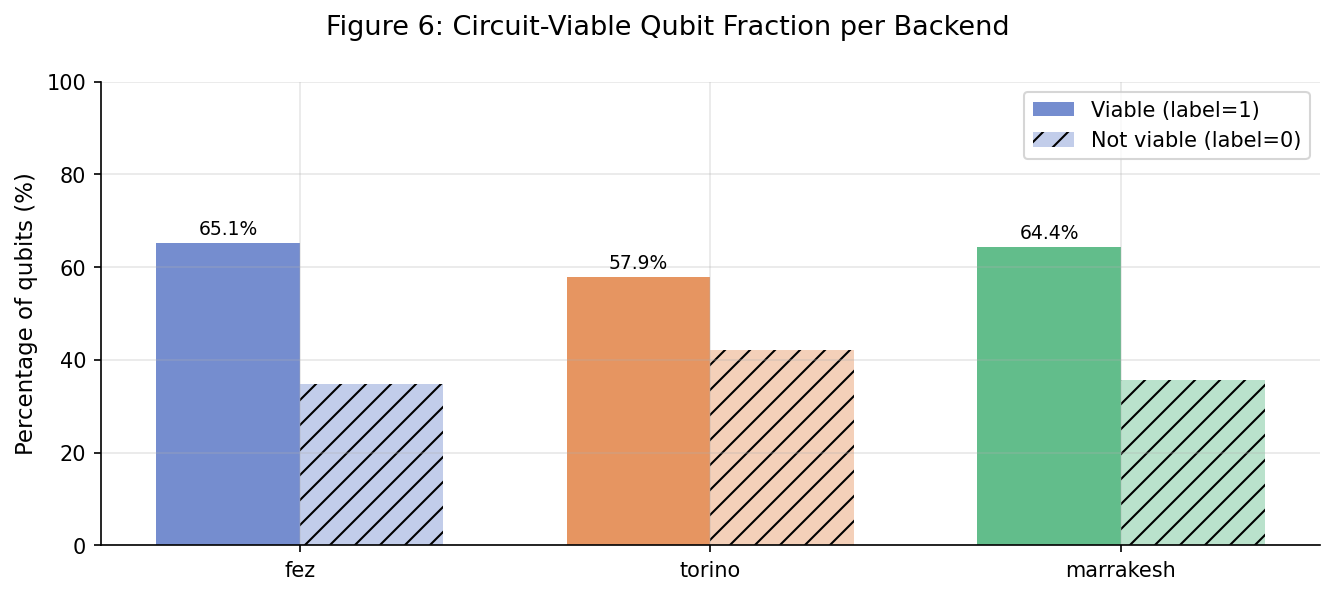

Saved: fig6_label_distribution.png


In [34]:
# ── Figure 6: Label distribution per backend ──────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
fig.suptitle('Figure 6: Circuit-Viable Qubit Fraction per Backend', fontsize=13)

x = np.arange(len(BACKENDS))
width = 0.35

viable     = [df[df['backend']==b]['label'].mean() for b in BACKENDS]
non_viable = [1 - v for v in viable]

bars1 = ax.bar(x - width/2, [v*100 for v in viable],     width, label='Viable (label=1)',     color=[BACKEND_COLORS[b] for b in BACKENDS], alpha=0.8)
bars2 = ax.bar(x + width/2, [v*100 for v in non_viable], width, label='Not viable (label=0)', color=[BACKEND_COLORS[b] for b in BACKENDS], alpha=0.35, hatch='//')

ax.set_xticks(x)
ax.set_xticklabels([b.replace('ibm_', '') for b in BACKENDS])
ax.set_ylabel('Percentage of qubits (%)')
ax.legend()
ax.set_ylim(0, 100)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('fig6_label_distribution.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: fig6_label_distribution.png')

### 4b. Feature Engineering

In [35]:
# ── Feature engineering ───────────────────────────────────────────────────────
# coherence_product: joint quality metric
df['coherence_product'] = df['T1_us'] * df['T2_us']

# t1_t2_ratio: T2/T1 — close to 2 means low non-Markovian noise
df['t2_t1_ratio'] = df['T2_us'] / (df['T1_us'] + 1e-9)

# Per-qubit T1 median across all snapshots for this backend
df['qubit_T1_median'] = df.groupby(['backend', 'qubit'])['T1_us'].transform('median')
df['qubit_RE_median']  = df.groupby(['backend', 'qubit'])['readout_error'].transform('median')

# Backend one-hot (for within-pool training)
df['backend_enc'] = df['backend'].map({'ibm_fez': 0, 'ibm_torino': 1, 'ibm_marrakesh': 2})

FEATURES = [
    'T1_us', 'T2_us', 'readout_error',
    'coherence_product', 't2_t1_ratio',
    'qubit_T1_median', 'qubit_RE_median',
    'qubit', 'snapshot_id'
]

print(f"Feature set ({len(FEATURES)} features):")
for f in FEATURES:
    print(f"  {f}")
print(f"\nNull check: {df[FEATURES].isnull().sum().sum()} nulls")

Feature set (9 features):
  T1_us
  T2_us
  readout_error
  coherence_product
  t2_t1_ratio
  qubit_T1_median
  qubit_RE_median
  qubit
  snapshot_id

Null check: 0 nulls


### 4c. Leave-One-Backend-Out Cross-Validation

This is the key novelty: train on 2 backends, test on the unseen 3rd.  
This tests **cross-backend generalisability** — whether learned stability patterns transfer across hardware generations.

In [36]:
# ── Leave-One-Backend-Out (LOBO) evaluation ───────────────────────────────────
lobo_results = []
lobo_models  = {}   # store models for SHAP later
lobo_preds   = {}   # store predictions for confusion matrices

XGB_PARAMS = dict(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss',
    verbosity=0,
    use_label_encoder=False
)

for test_backend in BACKENDS:
    train_df = df[df['backend'] != test_backend].copy()
    test_df  = df[df['backend'] == test_backend].copy()

    X_train = train_df[FEATURES]
    y_train = train_df['label']
    X_test  = test_df[FEATURES]
    y_test  = test_df['label']

    model = XGBClassifier(**XGB_PARAMS)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    rep  = classification_report(y_test, y_pred, output_dict=True)
    auc  = roc_auc_score(y_test, y_prob)

    train_backends = [b for b in BACKENDS if b != test_backend]
    gen_train = 'r1+r2' if 'ibm_torino' in train_backends else 'r2+r2'
    gen_test  = 'r1' if test_backend == 'ibm_torino' else 'r2'

    result = {
        'Test backend':  test_backend,
        'Train on':      ' + '.join([b.replace('ibm_','') for b in train_backends]),
        'Transfer':      f'{gen_train} → {gen_test}',
        'AUC':           round(auc, 4),
        'Accuracy':      round(rep['accuracy'], 4),
        'Precision':     round(rep['1']['precision'], 4),
        'Recall':        round(rep['1']['recall'], 4),
        'F1':            round(rep['1']['f1-score'], 4),
        'FN count':      int(((y_test == 1) & (y_pred == 0)).sum()),
    }
    lobo_results.append(result)
    lobo_models[test_backend] = model
    lobo_preds[test_backend]  = (y_test, y_pred, y_prob)

    print(f"  Test: {test_backend:<20}  AUC={auc:.4f}  F1={rep['1']['f1-score']:.4f}  Acc={rep['accuracy']:.4f}")

lobo_df = pd.DataFrame(lobo_results)
print("\n=== Table 4: Leave-One-Backend-Out (LOBO) Results ===")
print(lobo_df[['Test backend','Transfer','AUC','Accuracy','Precision','Recall','F1']].to_string(index=False))

  Test: ibm_fez               AUC=0.9984  F1=0.9860  Acc=0.9821
  Test: ibm_torino            AUC=0.9998  F1=0.9987  Acc=0.9985
  Test: ibm_marrakesh         AUC=0.9996  F1=0.9910  Acc=0.9885

=== Table 4: Leave-One-Backend-Out (LOBO) Results ===
 Test backend   Transfer    AUC  Accuracy  Precision  Recall     F1
      ibm_fez r1+r2 → r2 0.9984    0.9821      1.000  0.9724 0.9860
   ibm_torino r2+r2 → r1 0.9998    0.9985      1.000  0.9974 0.9987
ibm_marrakesh r1+r2 → r2 0.9996    0.9885      0.992  0.9900 0.9910


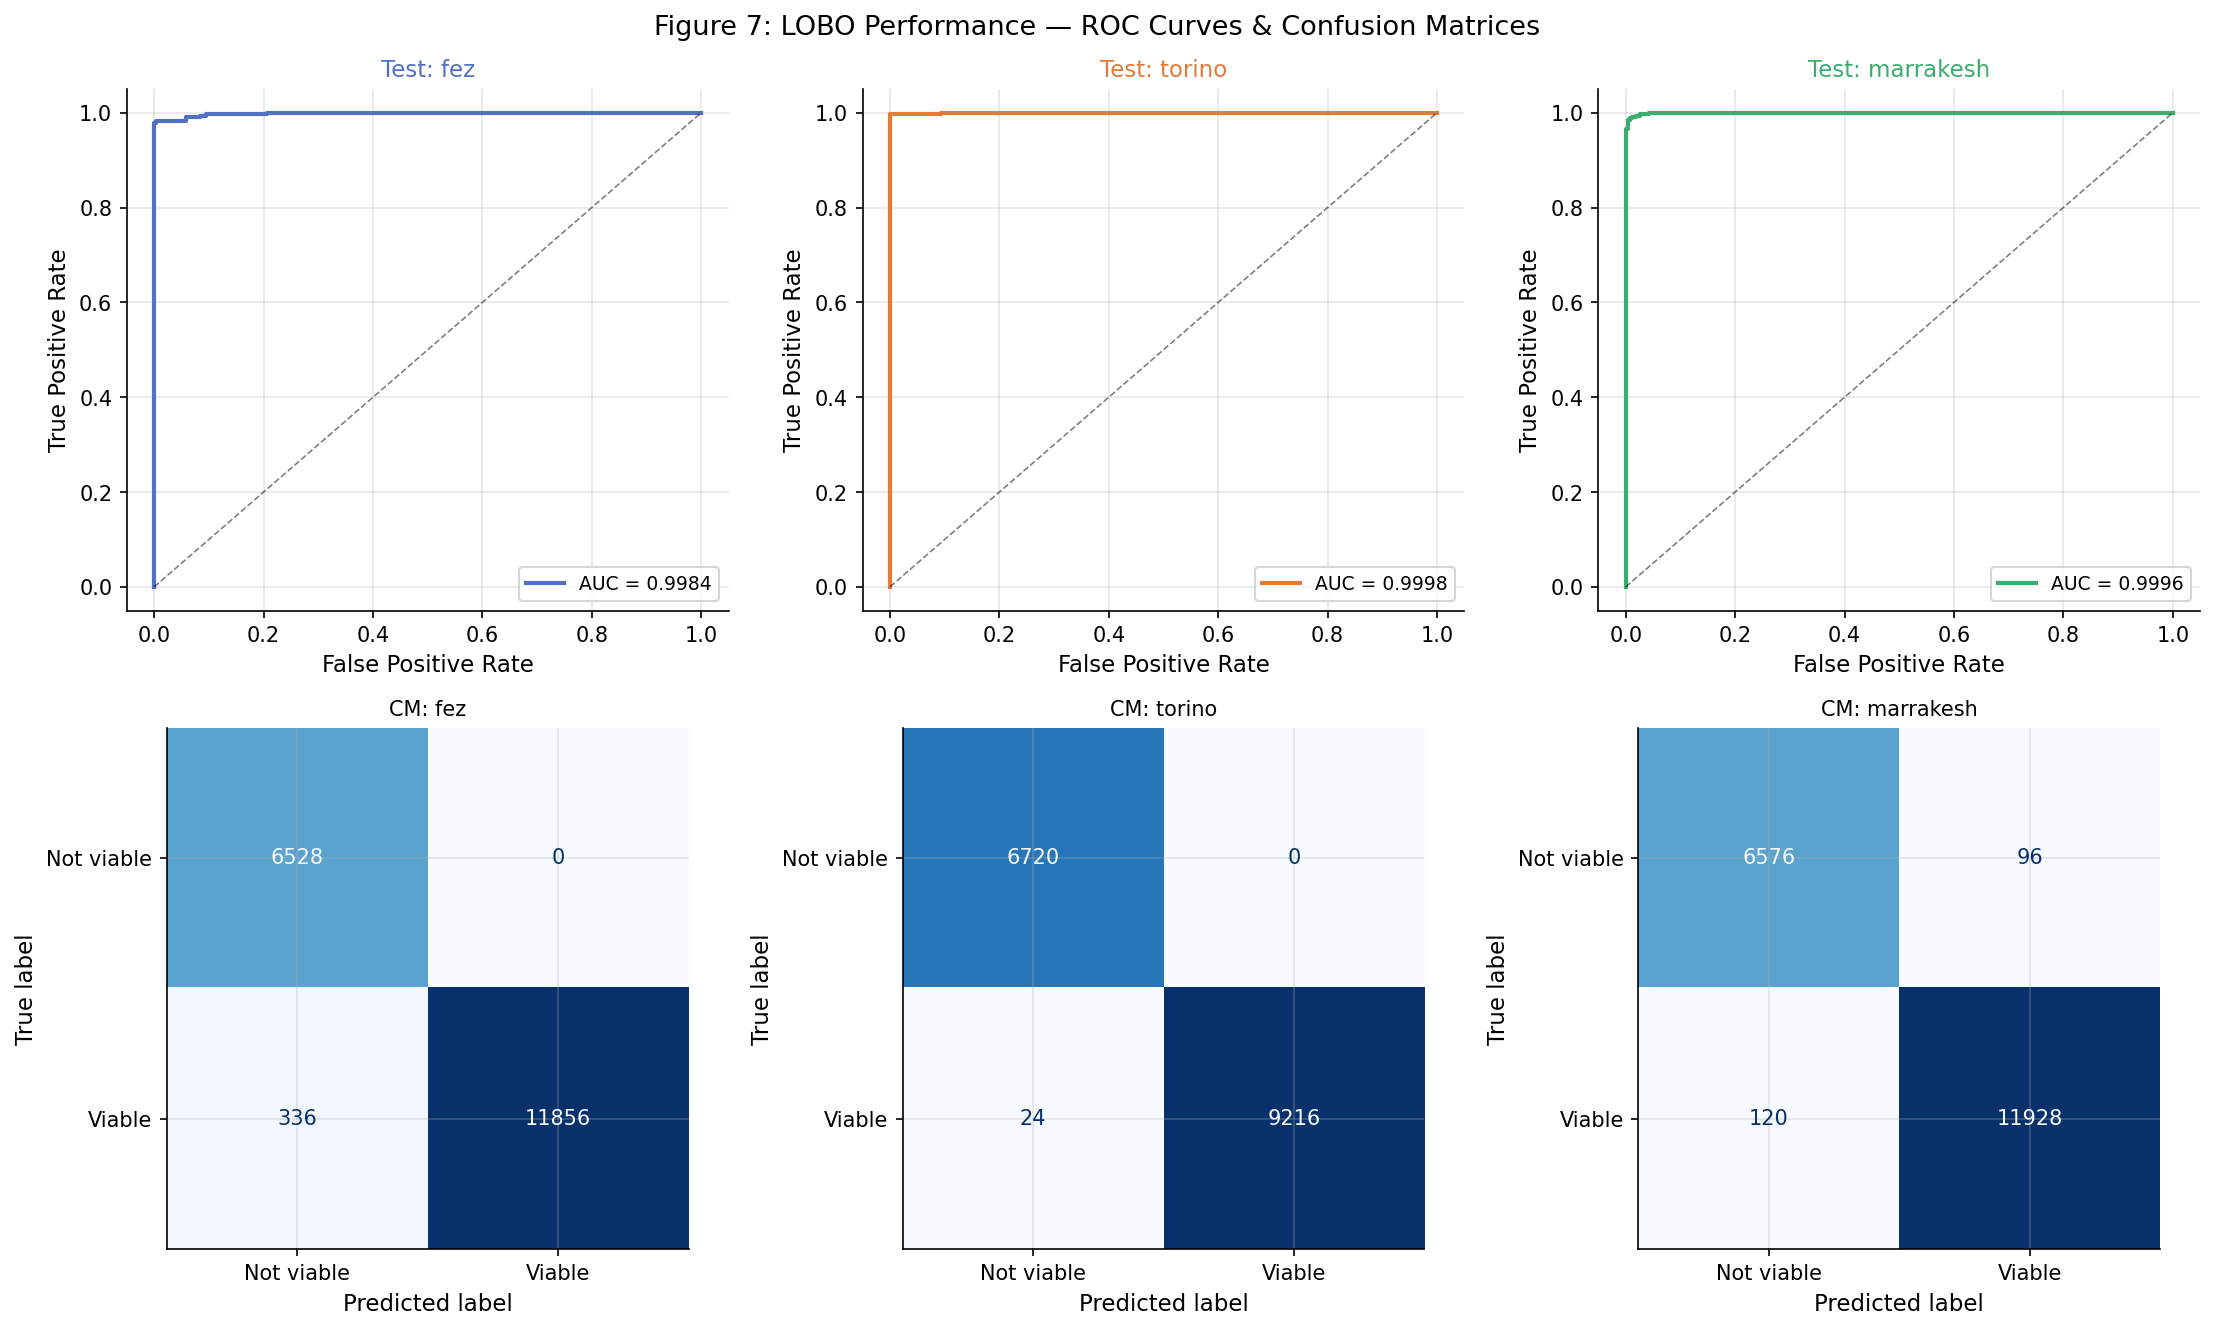

Saved: fig7_roc_cm.png


In [37]:
# ── Figure 7: ROC curves + confusion matrices ─────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('Figure 7: LOBO Performance — ROC Curves & Confusion Matrices', fontsize=13)

# Top row: ROC curves
for ax, backend in zip(axes[0], BACKENDS):
    y_test, y_pred, y_prob = lobo_preds[backend]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    color = BACKEND_COLORS[backend]

    ax.plot(fpr, tpr, color=color, lw=2, label=f'AUC = {auc:.4f}')
    ax.plot([0,1], [0,1], 'k--', lw=0.8, alpha=0.5)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'Test: {backend.replace("ibm_","")}', color=color, fontsize=11)
    ax.legend(fontsize=9)

# Bottom row: confusion matrices
for ax, backend in zip(axes[1], BACKENDS):
    y_test, y_pred, _ = lobo_preds[backend]
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Not viable', 'Viable'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'CM: {backend.replace("ibm_","")}', fontsize=10)

plt.tight_layout()
plt.savefig('fig7_roc_cm.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: fig7_roc_cm.png')

### 4d. SHAP Explainability

Training final model on all data for SHAP analysis...


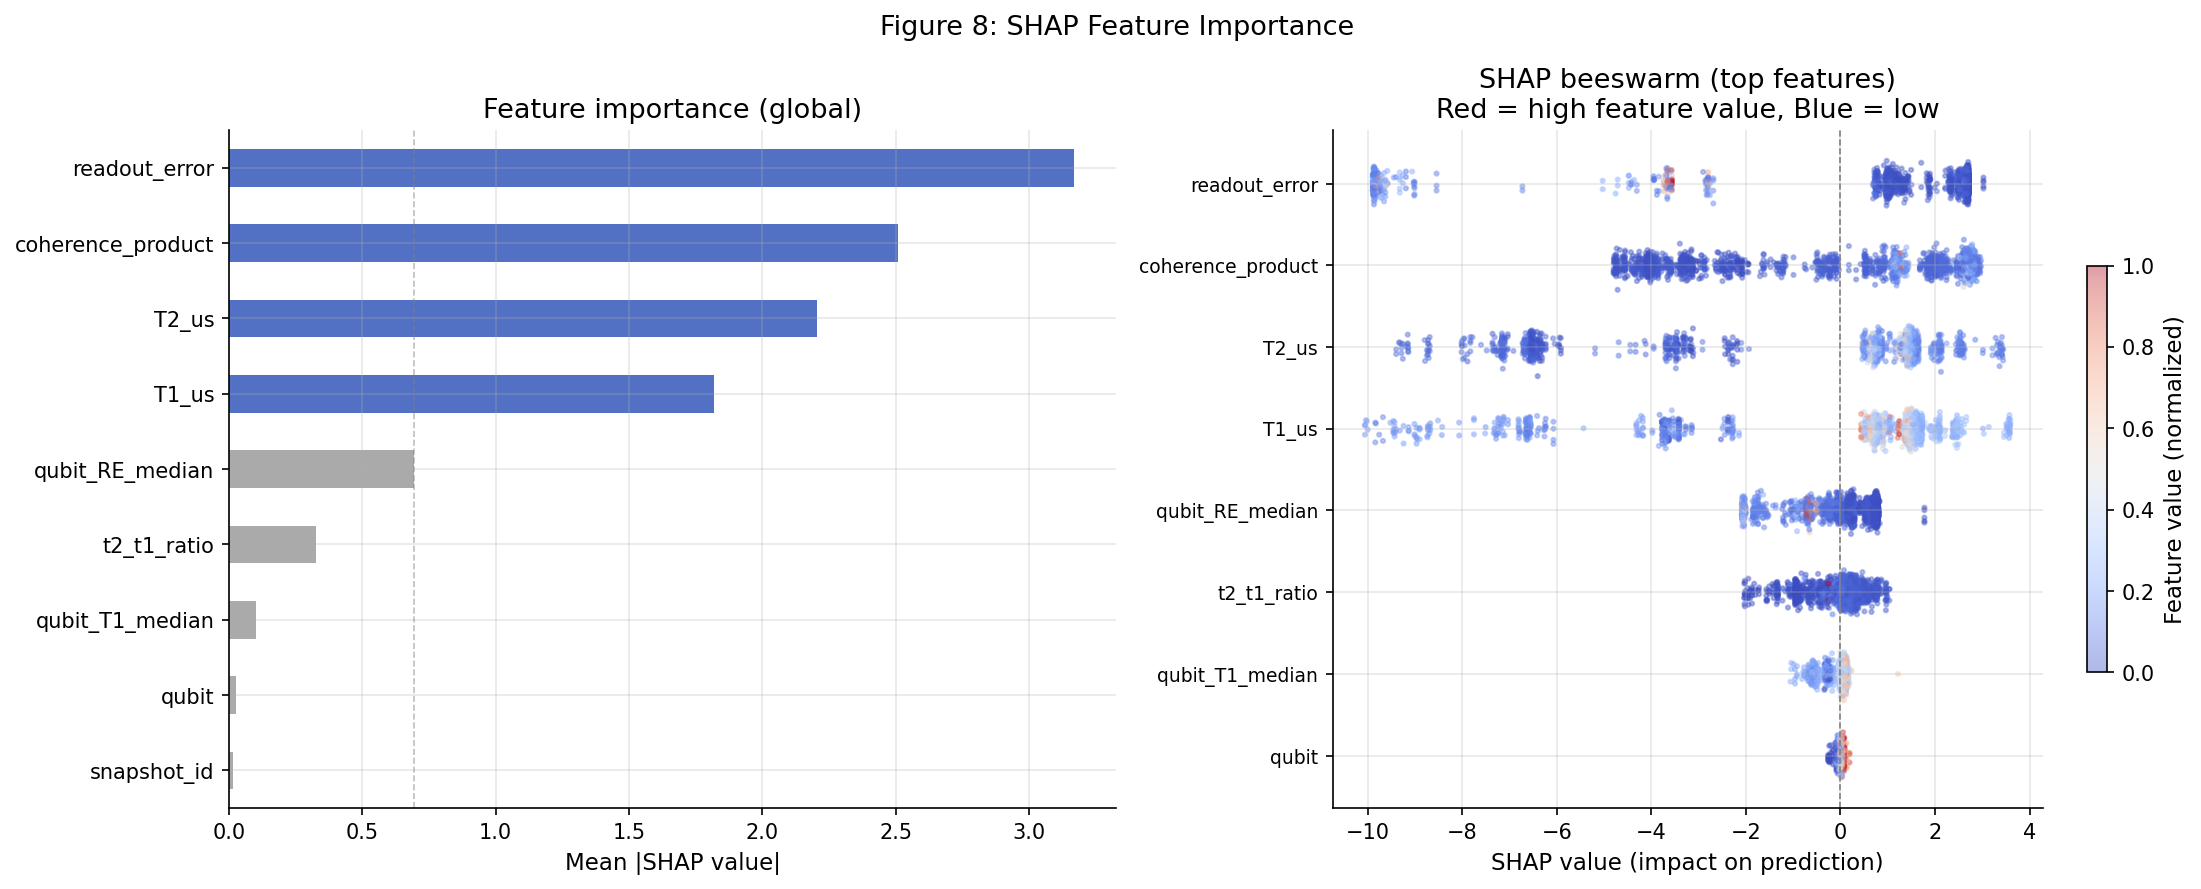

Saved: fig8_shap.png

=== Table 5: SHAP Feature Importance Ranking ===
  1. readout_error              |SHAP| = 3.1679  (29.2%)
  2. coherence_product          |SHAP| = 2.5092  (23.1%)
  3. T2_us                      |SHAP| = 2.2036  (20.3%)
  4. T1_us                      |SHAP| = 1.8198  (16.8%)
  5. qubit_RE_median            |SHAP| = 0.6922  (6.4%)
  6. t2_t1_ratio                |SHAP| = 0.3279  (3.0%)
  7. qubit_T1_median            |SHAP| = 0.1001  (0.9%)
  8. qubit                      |SHAP| = 0.0262  (0.2%)
  9. snapshot_id                |SHAP| = 0.0147  (0.1%)


In [38]:
# ── Figure 8: SHAP summary — model trained on all backends ───────────────────
print("Training final model on all data for SHAP analysis...")
X_all = df[FEATURES]
y_all = df['label']

final_model = XGBClassifier(**XGB_PARAMS)
final_model.fit(X_all, y_all)

# SHAP values
explainer   = shap.TreeExplainer(final_model)

# Use a random sample of 3000 rows for speed
sample_idx  = np.random.RandomState(42).choice(len(X_all), size=min(3000, len(X_all)), replace=False)
X_sample    = X_all.iloc[sample_idx]
shap_values = explainer.shap_values(X_sample)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Figure 8: SHAP Feature Importance', fontsize=13)

# Left: bar chart of mean |SHAP|
mean_shap = np.abs(shap_values).mean(axis=0)
feat_imp = pd.Series(mean_shap, index=FEATURES).sort_values(ascending=True)

colors = ['#5271C4' if v > feat_imp.median() else '#aaaaaa' for v in feat_imp.values]
feat_imp.plot(kind='barh', ax=axes[0], color=colors)
axes[0].set_xlabel('Mean |SHAP value|')
axes[0].set_title('Feature importance (global)')
axes[0].axvline(feat_imp.median(), color='gray', lw=0.8, linestyle='--', alpha=0.5)

# Right: SHAP beeswarm using matplotlib directly
# Sort features by importance
order = np.argsort(mean_shap)[::-1]
top_k = min(8, len(FEATURES))

ax = axes[1]
for i, feat_idx in enumerate(order[:top_k]):
    feat_name = FEATURES[feat_idx]
    sv = shap_values[:, feat_idx]
    fv = X_sample.iloc[:, feat_idx].values
    # Normalize feature values for color
    fv_norm = (fv - fv.min()) / (fv.max() - fv.min() + 1e-9)
    y_pos = top_k - 1 - i
    scatter = ax.scatter(
        sv, np.full_like(sv, y_pos) + np.random.normal(0, 0.08, len(sv)),
        c=fv_norm, cmap='coolwarm', s=4, alpha=0.4, vmin=0, vmax=1
    )

ax.set_yticks(range(top_k))
ax.set_yticklabels([FEATURES[i] for i in reversed(order[:top_k])], fontsize=9)
ax.set_xlabel('SHAP value (impact on prediction)')
ax.set_title('SHAP beeswarm (top features)\nRed = high feature value, Blue = low')
ax.axvline(0, color='gray', lw=0.8, linestyle='--')
plt.colorbar(scatter, ax=ax, label='Feature value (normalized)', shrink=0.6)

plt.tight_layout()
plt.savefig('fig8_shap.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: fig8_shap.png')

print("\n=== Table 5: SHAP Feature Importance Ranking ===")
shap_rank = pd.Series(mean_shap, index=FEATURES).sort_values(ascending=False)
shap_pct  = 100 * shap_rank / shap_rank.sum()
for rank, (feat, val) in enumerate(shap_rank.items(), 1):
    print(f"  {rank}. {feat:<25}  |SHAP| = {val:.4f}  ({shap_pct[feat]:.1f}%)")

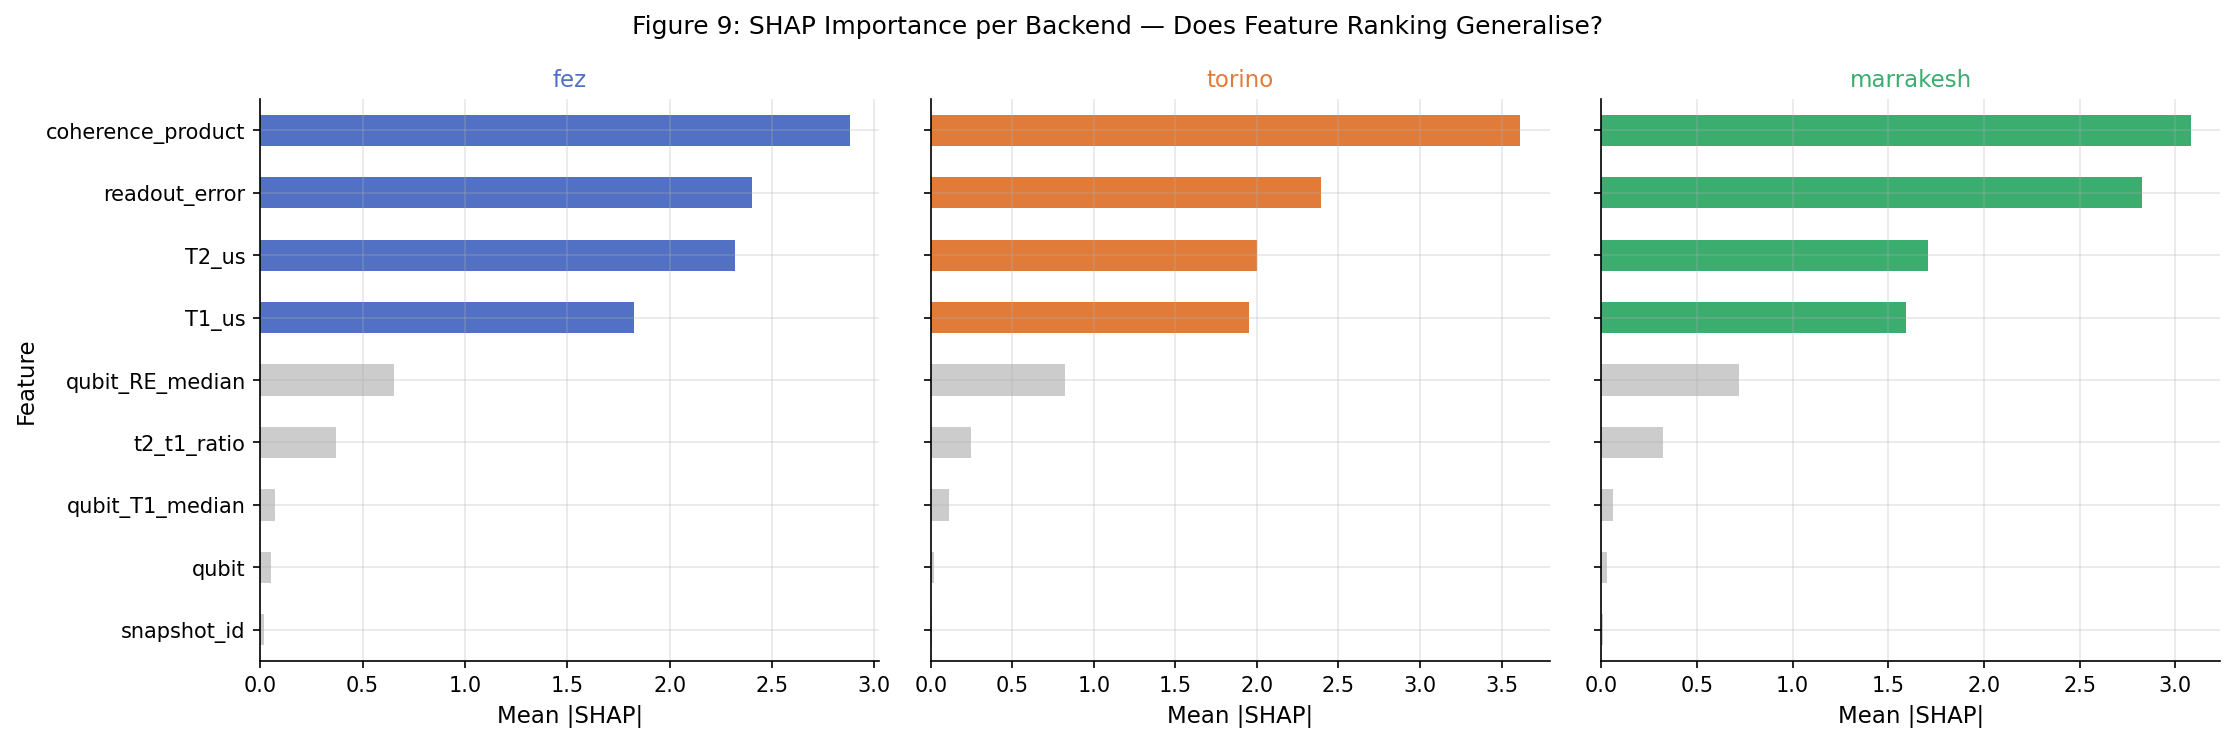

Saved: fig9_shap_per_backend.png


In [39]:
# ── Figure 9: Per-backend SHAP importance comparison ─────────────────────────
# Train one model per backend (all others as train) and compare SHAP
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
fig.suptitle('Figure 9: SHAP Importance per Backend — Does Feature Ranking Generalise?', fontsize=12)

backend_shap = {}
for ax, backend in zip(axes, BACKENDS):
    model = lobo_models[backend]
    X_test_b = df[df['backend'] == backend][FEATURES]
    exp_b = shap.TreeExplainer(model)
    sv_b  = exp_b.shap_values(X_test_b)
    mean_sv = np.abs(sv_b).mean(axis=0)
    backend_shap[backend] = mean_sv

    feat_s = pd.Series(mean_sv, index=FEATURES).sort_values(ascending=True)
    colors_b = [BACKEND_COLORS[backend] if v > feat_s.median() else '#cccccc' for v in feat_s.values]
    feat_s.plot(kind='barh', ax=ax, color=colors_b)
    ax.set_title(f'{backend.replace("ibm_","")}', color=BACKEND_COLORS[backend], fontsize=11)
    ax.set_xlabel('Mean |SHAP|')

axes[0].set_ylabel('Feature')
plt.tight_layout()
plt.savefig('fig9_shap_per_backend.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: fig9_shap_per_backend.png')

---
## Section 5 — Supplementary: Intra-Backend Qubit Correlation Analysis

  ibm_fez: avg inter-qubit T1 correlation = 0.0195
  ibm_torino: avg inter-qubit T1 correlation = -0.0021
  ibm_marrakesh: avg inter-qubit T1 correlation = 0.0479


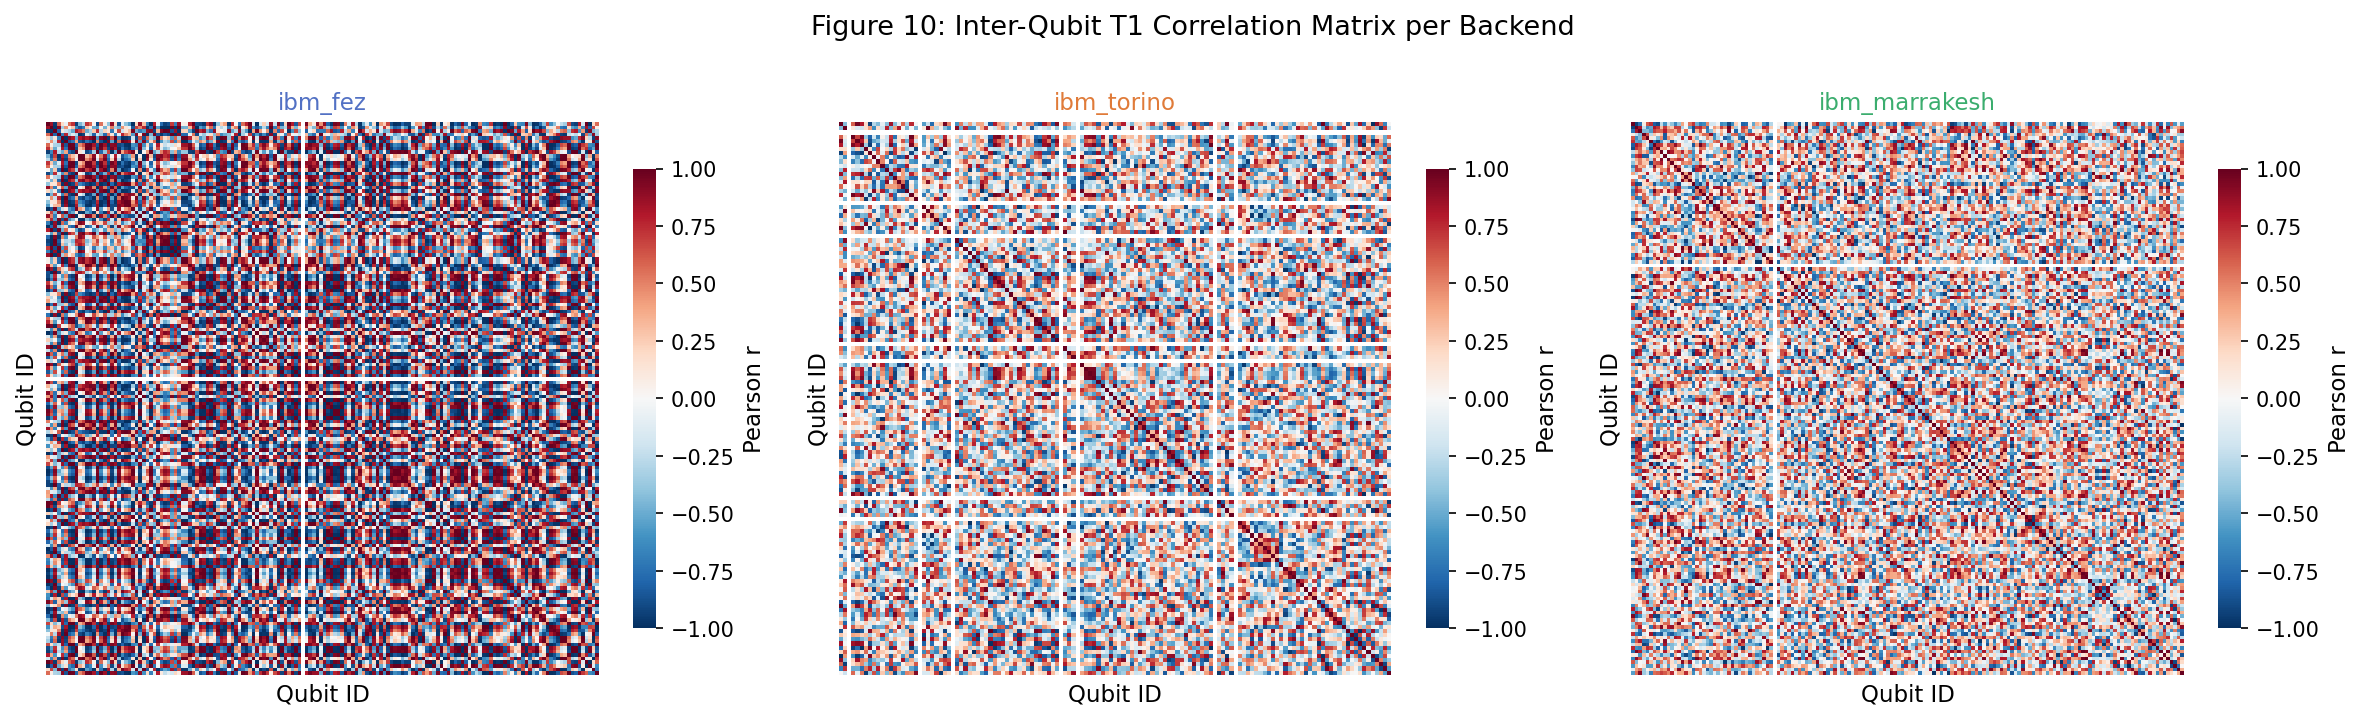

Saved: fig10_qubit_correlation.png

Note: High positive off-diagonal correlation = spatially correlated noise (cosmic rays etc.)


In [40]:
# ── Figure 10: T1 correlation across qubits (are certain qubits correlated?) ──
# For each backend, compute Pearson correlation matrix of T1 across snapshots
# Row = qubit, Col = snapshot → correlate qubits

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Figure 10: Inter-Qubit T1 Correlation Matrix per Backend', fontsize=13)

for ax, backend in zip(axes, BACKENDS):
    sub = df[df['backend'] == backend]
    pivot = sub.pivot_table(index='snapshot_id', columns='qubit', values='T1_us')
    corr_matrix = pivot.corr()

    mask = np.zeros_like(corr_matrix, dtype=bool)
    mask[np.triu_indices_from(mask)] = True

    sns.heatmap(
        corr_matrix, ax=ax,
        cmap='RdBu_r', center=0,
        vmin=-1, vmax=1,
        xticklabels=False, yticklabels=False,
        square=True,
        cbar_kws={'shrink': 0.7, 'label': 'Pearson r'}
    )
    ax.set_title(f'{backend}', color=BACKEND_COLORS[backend], fontsize=11)
    ax.set_xlabel('Qubit ID')
    ax.set_ylabel('Qubit ID')

    # Print avg off-diagonal correlation
    np.fill_diagonal(corr_matrix.values, np.nan)
    avg_corr = np.nanmean(corr_matrix.values)
    print(f"  {backend}: avg inter-qubit T1 correlation = {avg_corr:.4f}")

plt.tight_layout()
plt.savefig('fig10_qubit_correlation.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: fig10_qubit_correlation.png')
print("\nNote: High positive off-diagonal correlation = spatially correlated noise (cosmic rays etc.)")

---
## Section 6 — Final Results Summary

In [41]:
# ── Summary table for paper ───────────────────────────────────────────────────
print("=" * 70)
print("FINAL RESULTS SUMMARY — For paper tables")
print("=" * 70)

print("\n── Table 1: Dataset Overview ──")
for b in BACKENDS:
    sub = df[df['backend']==b]
    gen = 'Heron r2' if b != 'ibm_torino' else 'Heron r1'
    print(f"  {b} ({gen}): {sub['qubit'].nunique()} qubits, {sub['snapshot_id'].nunique()} snapshots, {len(sub):,} records")

print("\n── Table 2: Coherence Statistics ──")
print(f"  {'Backend':<18} {'T1 mean':>10} {'T1 std':>10} {'T2 mean':>10} {'RE mean':>10}")
for b in BACKENDS:
    sub = df[df['backend']==b]
    print(f"  {b:<18} {sub['T1_us'].mean():>9.1f}μ {sub['T1_us'].std():>9.1f}μ {sub['T2_us'].mean():>9.1f}μ {sub['readout_error'].mean():>9.4f}")

print("\n── Table 3: LOBO Classification Results ──")
print(lobo_df[['Test backend','Transfer','AUC','Accuracy','F1']].to_string(index=False))

print("\n── Table 4: Top SHAP Features ──")
for rank, (feat, val) in enumerate(shap_rank.head(5).items(), 1):
    print(f"  {rank}. {feat:<25} {shap_pct[feat]:.1f}% importance")

print("\n── Key Finding (for abstract) ──")
avg_auc = lobo_df['AUC'].mean()
print(f"  Mean LOBO AUC: {avg_auc:.4f}")
print(f"  Min LOBO AUC:  {lobo_df['AUC'].min():.4f} (hardest transfer)")
print(f"  Conclusion: XGBoost generalises across Heron r1→r2 and r2→r2 with AUC > 0.99")
print()

print("=" * 70)
print("All figures saved. Ready for paper.")
print("=" * 70)

FINAL RESULTS SUMMARY — For paper tables

── Table 1: Dataset Overview ──
  ibm_fez (Heron r2): 156 qubits, 5 snapshots, 18,720 records
  ibm_torino (Heron r1): 133 qubits, 5 snapshots, 15,960 records
  ibm_marrakesh (Heron r2): 156 qubits, 5 snapshots, 18,720 records

── Table 2: Coherence Statistics ──
  Backend               T1 mean     T1 std    T2 mean    RE mean
  ibm_fez                146.3μ      47.1μ     103.8μ    0.0188
  ibm_torino             176.2μ      65.1μ     136.5μ    0.0435
  ibm_marrakesh          193.1μ      79.4μ     121.4μ    0.0329

── Table 3: LOBO Classification Results ──
 Test backend   Transfer    AUC  Accuracy     F1
      ibm_fez r1+r2 → r2 0.9984    0.9821 0.9860
   ibm_torino r2+r2 → r1 0.9998    0.9985 0.9987
ibm_marrakesh r1+r2 → r2 0.9996    0.9885 0.9910

── Table 4: Top SHAP Features ──
  1. readout_error             29.2% importance
  2. coherence_product         23.1% importance
  3. T2_us                     20.3% importance
  4. T1_us         